In [13]:
import os
# '..' tells the computer to look at the folder above this one
print(f"Contents of the root project folder: {os.listdir('..')}")
print(f"Contents of the data folder: {os.listdir('../data')}")

Contents of the root project folder: ['.git', '.gitignore', 'data', 'environment.yml', 'med_ai_env', 'models', 'notebooks', 'README.md', 'scripts', 'src']
Contents of the data folder: ['test', 'train', 'val']


In [14]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define image transformations (Resizing to 224x224 is standard for models like ResNet)
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard ImageNet stats
])

# 2. Point to your local data directories
data_dir = '../data' # Adjusted for your folder structure
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms)
                  for x in ['train', 'val', 'test']}

# 3. Create the DataLoaders
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True)
               for x in ['train', 'val', 'test']}

print(f"Data loading complete. Training samples: {len(image_datasets['train'])}")

Data loading complete. Training samples: 5216


In [15]:
for x in ['train', 'val', 'test']:
    normal_count = len(os.listdir(f'../data/{x}/NORMAL'))
    pneumonia_count = len(os.listdir(f'../data/{x}/PNEUMONIA'))
    print(f"{x.capitalize()} Set - Normal: {normal_count}, Pneumonia: {pneumonia_count}")

Train Set - Normal: 1341, Pneumonia: 3875
Val Set - Normal: 8, Pneumonia: 8
Test Set - Normal: 234, Pneumonia: 390


In [16]:
# Updated Transforms with Augmentation for the Training Set
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),      # Flips the image horizontally
    transforms.RandomRotation(10),           # Small rotations (don't over-rotate x-rays!)
    transforms.ColorJitter(brightness=0.1), # Slight lighting changes
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Keep Test/Val transforms simple (no augmentation here)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [17]:
# Check if the DataLoader can actually 'see' the images
train_data_size = len(image_datasets['train'])
class_names = image_datasets['train'].classes

print(f"Total training images detected: {train_data_size}")
print(f"Classes found: {class_names}")

Total training images detected: 5216
Classes found: ['NORMAL', 'PNEUMONIA']


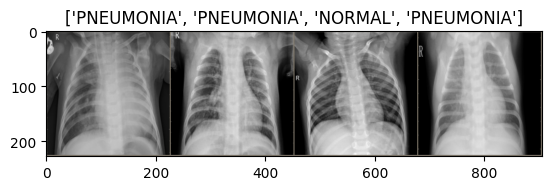

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs[:4]) 

imshow(out, title=[class_names[x] for x in classes[:4]])

In [19]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Load pre-trained ResNet50
model = models.resnet50(weights='IMAGENET1K_V1')

# 2. Freeze the 'backbone' layers so we don't destroy pre-trained knowledge
for param in model.parameters():
    param.requires_grad = False

# 3. Replace the final layer (fc) with a custom binary classifier
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) # 2 classes: Normal and Pneumonia

# 4. Move model to your RTX 4090
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model initialized and moved to: {device}")

Model initialized and moved to: cuda:0


In [20]:
import torch.optim as optim

# 1. Define the weights to handle the 3:1 imbalance
# We give more weight to the minority class (Normal)
weights = torch.tensor([3.0, 1.0]).to(device) 
criterion = nn.CrossEntropyLoss(weight=weights)

# 2. Define the Optimizer (Adam is standard for medical imaging)
# We only optimize the parameters of the 'fc' layer we just replaced
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("Loss function with class weights and Adam optimizer are ready.")

Loss function with class weights and Adam optimizer are ready.


In [33]:
def train_model(model, criterion, optimizer, num_epochs=5):
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])

            print(f'{phase} Loss: {epoch_loss:.4} Acc: {epoch_acc:.4}')

    return model

# Start training!
model = train_model(model, criterion, optimizer, num_epochs=5)

Epoch 1/5
----------
train Loss: 0.1354 Acc: 0.9445
val Loss: 0.07308 Acc: 0.9665
Epoch 2/5
----------
train Loss: 0.07305 Acc: 0.9756
val Loss: 0.0728 Acc: 0.9788
Epoch 3/5
----------
train Loss: 0.04764 Acc: 0.9817
val Loss: 0.04612 Acc: 0.987
Epoch 4/5
----------
train Loss: 0.04211 Acc: 0.9841
val Loss: 0.03633 Acc: 0.9829
Epoch 5/5
----------
train Loss: 0.03742 Acc: 0.9875
val Loss: 0.047 Acc: 0.9829


In [29]:
import os
# Create a models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the weights to your local folder
torch.save(model.state_dict(), '../models/pneumonia_resnet50_v1.pth')
print("Weights saved to: medical-image-classification/models/pneumonia_resnet50_v1.pth")

Weights saved to: medical-image-classification/models/pneumonia_resnet50_v1.pth


In [34]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define the test path (stepping up from /notebooks to /data)
test_dir = '../data/test'

# 2. Define transforms (Resize and Normalize only—no augmentation for testing)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. Initialize the Test Dataset and Loader
test_dataset = datasets.ImageFolder(test_dir, test_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 4. Run the Evaluation
model.eval() 
test_corrects = 0

print(f"Starting evaluation on {len(test_dataset)} test images...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)

test_acc = test_corrects.double() / len(test_dataset)
print(f"---")
print(f"Final Test Accuracy: {test_acc:.4f}")

Starting evaluation on 624 test images...
---
Final Test Accuracy: 0.8061


In [27]:
import os
import random
import shutil

# Paths based on your structure
train_dir = '../data/train'
val_dir = '../data/val'

for cls in ['NORMAL', 'PNEUMONIA']:
    source = os.path.join(train_dir, cls)
    dest = os.path.join(val_dir, cls)
    
    # Get all images in training for this class
    files = os.listdir(source)
    # Move 15% of them to validation
    num_to_move = int(len(files) * 0.15)
    to_move = random.sample(files, num_to_move)
    
    for f in to_move:
        shutil.move(os.path.join(source, f), os.path.join(dest, f))

print("Folders re-balanced. Validation set is now large enough to be meaningful.")

Folders re-balanced. Validation set is now large enough to be meaningful.


In [26]:
# 1. Load a fresh pre-trained model
model = models.resnet50(weights='IMAGENET1K_V1')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# 2. DO NOT freeze the layers this time. Let the whole model learn.
for param in model.parameters():
    param.requires_grad = True

model = model.to(device)

# 3. Use a much smaller learning rate (0.0001 instead of 0.001)
# This is crucial for fine-tuning!
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 4. Use the same weighted loss to handle the 3:1 imbalance
weights = torch.tensor([3.0, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

print("Fine-tuning mode active. All layers are now learning.")

Fine-tuning mode active. All layers are now learning.


In [32]:
# 1. Reset the directory (moving up one level from /notebooks)
data_dir = '../data' 

# 2. Redefine the dictionary of transforms
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 3. Re-initialize the datasets and loaders
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val']}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True)
               for x in ['train', 'val']}

print(f"Training images: {len(image_datasets['train'])}")
print(f"Validation images: {len(image_datasets['val'])}")

Training images: 3769
Validation images: 1463


In [36]:
# Save the high-performing fine-tuned weights
torch.save(model.state_dict(), '../models/pneumonia_resnet50_finetuned_v2.pth')
print("High-performance model saved to models/pneumonia_resnet50_finetuned_v2.pth")

High-performance model saved to models/pneumonia_resnet50_finetuned_v2.pth
